In [1]:
import pandas as pd

df = pd.read_csv("fifa_worldcup.csv")

print(df.head())

   goals_scored  possession  shots_on_target  passes_completed  fouls  result
0             3          57                8               577      5       1
1             4          44                8               512     11       1
2             2          44               11               471     17       1
3             4          53                1               587     19       1
4             4          51                8               473     14       1


In [2]:
X = df.drop("result", axis=1)
y = df["result"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')  # try 'linear' bhi

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 1 1 1 0 1 1 0 1 1]


In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.93125

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91        61
           1       0.95      0.94      0.94        99

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160


Confusion Matrix:
 [[56  5]
 [ 6 93]]


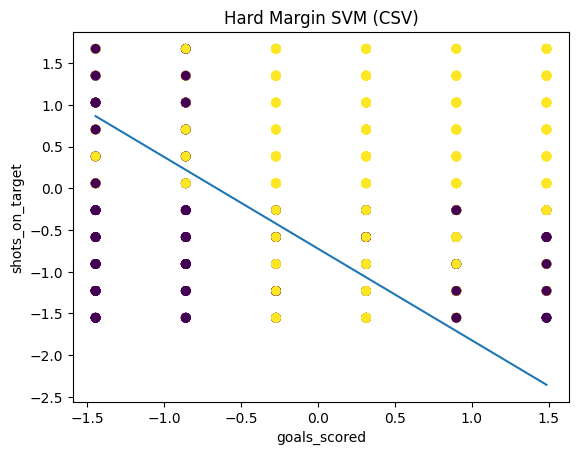

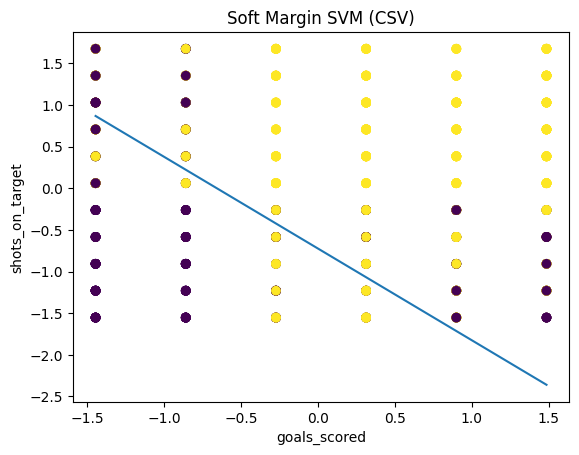

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 🔹 2 features select (visualization ke liye)
X = df[['goals_scored', 'shots_on_target']]
y = df['result']

# 🔹 Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 Models
hard_model = SVC(kernel='linear', C=1000)
soft_model = SVC(kernel='linear', C=0.1)

hard_model.fit(X_scaled, y)
soft_model.fit(X_scaled, y)


# 🔹 Plot Function (FAST VERSION)
def plot_svm(model, X, y, title):
    plt.figure()
    
    plt.scatter(X[:, 0], X[:, 1], c=y)

    # decision boundary
    w = model.coef_[0]
    b = model.intercept_[0]

    x_points = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    y_points = -(w[0]*x_points + b) / w[1]

    plt.plot(x_points, y_points)

    plt.title(title)
    plt.xlabel("goals_scored")
    plt.ylabel("shots_on_target")
    plt.show()


# 🔹 Plot
plot_svm(hard_model, X_scaled, y, "Hard Margin SVM (CSV)")
plot_svm(soft_model, X_scaled, y, "Soft Margin SVM (CSV)")

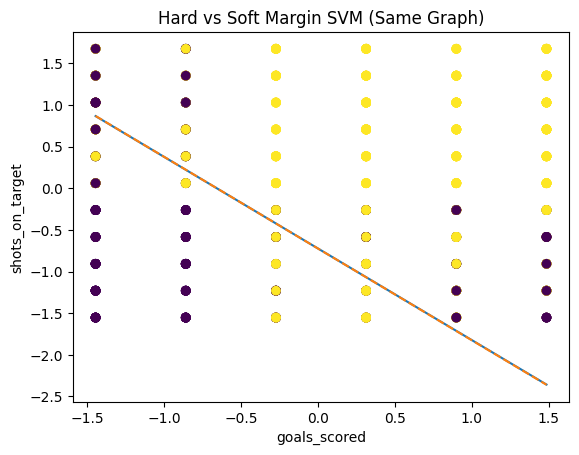

In [10]:
# 🔹 2 features (visualization ke liye)
X = df[['goals_scored', 'shots_on_target']].values
y = df['result'].values

# 🔹 Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 Train Models
hard_model = SVC(kernel='linear', C=1000)
soft_model = SVC(kernel='linear', C=0.1)

hard_model.fit(X_scaled, y)
soft_model.fit(X_scaled, y)

# 🔹 Plot
plt.figure()

# Data points
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)

# X range
x_vals = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)

# 🔹 Hard Margin Line
w_h = hard_model.coef_[0]
b_h = hard_model.intercept_[0]
y_h = -(w_h[0]*x_vals + b_h) / w_h[1]
plt.plot(x_vals, y_h, linestyle='-')

# 🔹 Soft Margin Line
w_s = soft_model.coef_[0]
b_s = soft_model.intercept_[0]
y_s = -(w_s[0]*x_vals + b_s) / w_s[1]
plt.plot(x_vals, y_s, linestyle='--')

# Labels
plt.title("Hard vs Soft Margin SVM (Same Graph)")
plt.xlabel("goals_scored")
plt.ylabel("shots_on_target")

plt.show()